# Actividad 2

### Definición del problema:
__Objetivo__: Analizar el comportamiento de ventas y la calidad de los productos de "La Granja de Lu" para optimizar el inventario y reducir mermas.

__Preguntas clave__:
1. ¿Cuál es el promedio de ventas por categoría?
2. ¿Existe relación entre el precio del producto y su nivel de maduración?
3. ¿Cómo se distribuyen los días de vida útil restantes de los productos?


### Generación de Datos Aleatorios



In [5]:
import pandas as pd
import numpy as np
import random
from pymongo import MongoClient

# 1. Generación de datos aleatorios
n = 5000
categorias = ['Frutas', 'Verduras', 'Cítricos', 'Exóticos']
unidades = ['Kg', 'Pieza', 'Manojo']

data = {
    # 4 Numéricas
    "precio_venta": np.random.uniform(15.0, 200.0, n).round(2),
    "cantidad_stock": np.random.randint(10, 500, n),
    "dias_anaquel": np.random.randint(1, 15, n),
    "costo_proveedor": np.random.uniform(5.0, 100.0, n).round(2),

    # 2 Categóricas
    "categoria": [random.choice(categorias) for _ in range(n)],
    "unidad": [random.choice(unidades) for _ in range(n)],

    # 2 Estructuradas (Diccionarios/Objetos)
    "detalles_envio": [{"bodega": random.randint(1, 5), "refrigerado": random.choice([True, False])} for _ in range(n)],
    "info_nutricional": [{"calorias": random.randint(30, 150), "fibra_g": 2.5} for _ in range(n)],

    # 2 No Estructuradas (Texto libre)
    "resena_cliente": [f"El producto llegó en estado {random.choice(['excelente', 'regular', 'bueno'])}" for _ in range(n)],
    "notas_calidad": ["Revisar maduración antes de exhibir" for _ in range(n)]
}

df = pd.DataFrame(data)

# 2. Mostrar datos
print("\nEstructura de los datos:")
print(df.info())


Estructura de los datos:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   precio_venta      5000 non-null   float64
 1   cantidad_stock    5000 non-null   int64  
 2   dias_anaquel      5000 non-null   int64  
 3   costo_proveedor   5000 non-null   float64
 4   categoria         5000 non-null   str    
 5   unidad            5000 non-null   str    
 6   detalles_envio    5000 non-null   object 
 7   info_nutricional  5000 non-null   object 
 8   resena_cliente    5000 non-null   str    
 9   notas_calidad     5000 non-null   str    
dtypes: float64(2), int64(2), object(2), str(4)
memory usage: 390.8+ KB
None


### Subir los datos a mongo

In [6]:
client = MongoClient('mongodb://localhost:27017/')
db = client['fruteria_integradora']
coleccion = db['productos']
coleccion.drop() # Limpiamos para evitar duplicados en pruebas
coleccion.insert_many(df.to_dict('records'))
print("Datos cargados exitosamente a MongoDB.")

Datos cargados exitosamente a MongoDB.


### Análisis Exploratorio de Datos

In [7]:
# Resumen estadístico de datos numéricos
columnas_num = ["precio_venta", "cantidad_stock", "dias_anaquel", "costo_proveedor"]

# Creamos un DataFrame para el resumen
resumen_stats = pd.DataFrame({
    "Media": df[columnas_num].mean(),
    "Mediana": df[columnas_num].median(),
    "Moda": df[columnas_num].mode().iloc[0]
})

print("\n--- RESUMEN ESTADÍSTICO ---")
print(resumen_stats)

# Exploración de categóricos (Moda)
print("\nModa de categorías:", df['categoria'].mode()[0])


--- RESUMEN ESTADÍSTICO ---
                      Media  Mediana    Moda
precio_venta     108.944050  109.365   61.55
cantidad_stock   256.817200  257.000  278.00
dias_anaquel       7.410400    7.000    2.00
costo_proveedor   52.609006   52.845   28.90

Moda de categorías: Verduras


__Interpretación del Análisis Exploratorio__:
Los datos muestran una distribución equilibrada. El precio de venta promedio ronda los $109 MXN, lo cual es coherente con el rango establecido. La mediana del stock nos indica que la mayoría de los productos tienen una existencia de 257 unidades, asegurando que no haya desabasto inmediato. Al no haber valores nulos en el resumen, confirmamos la calidad de la

/tmp/ipykernel_14828/1615052125.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='categoria', y='precio_venta', data=df, palette='Set2')


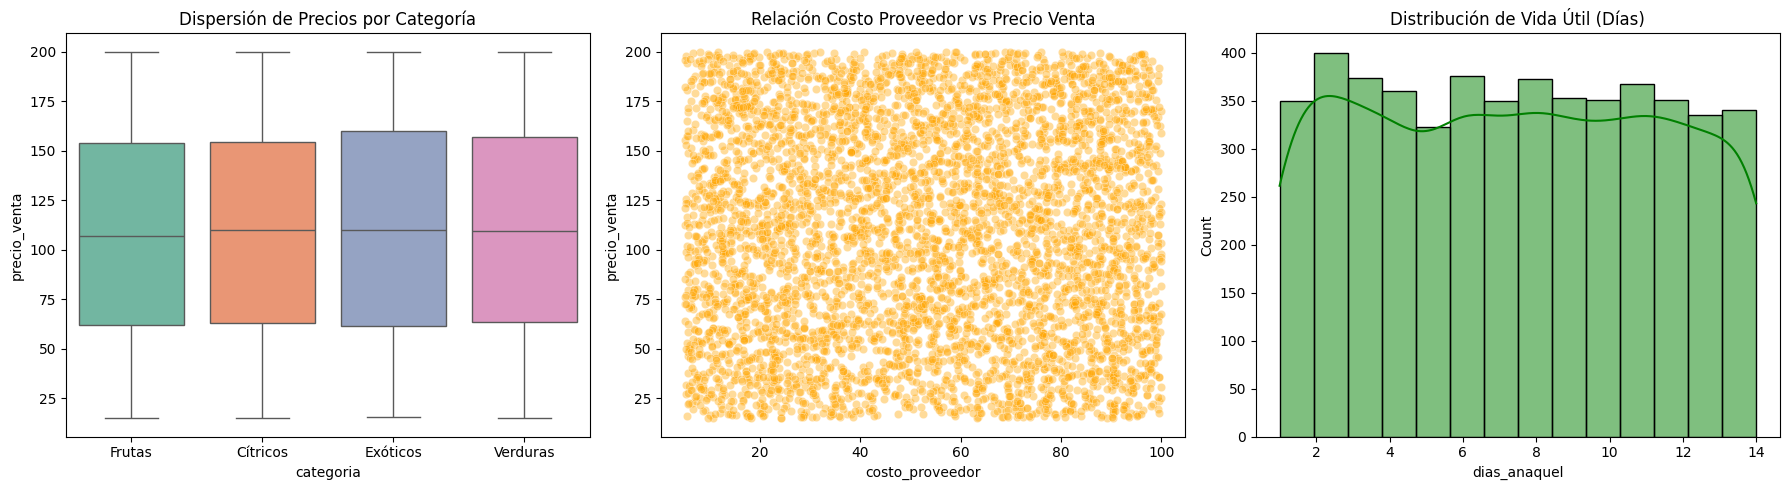

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

# 1. Diagrama de Cajas (Boxplot) - Distribución de precios por categoría
plt.subplot(1, 3, 1)
sns.boxplot(x='categoria', y='precio_venta', data=df, palette='Set2')
plt.title('Dispersión de Precios por Categoría')

# 2. Gráfica de Dispersión (Scatter) - Relación Costo vs Precio
plt.subplot(1, 3, 2)
sns.scatterplot(x='costo_proveedor', y='precio_venta', data=df, alpha=0.4, color='orange')
plt.title('Relación Costo Proveedor vs Precio Venta')

# 3. Histograma - Distribución de Días en Anaquel
plt.subplot(1, 3, 3)
sns.histplot(df['dias_anaquel'], bins=14, kde=True, color='green')
plt.title('Distribución de Vida Útil (Días)')

plt.tight_layout()
plt.show()

__Interpretación de las Gráficas__:

- __Diagrama de Cajas__: Muestra que todas las categorías tienen un rango de precios similar (entre $60 y $160). La simetría de las cajas indica que no hay un sesgo hacia productos extremadamente caros o baratos dentro de una sola categoría.

- __Gráfica de Dispersión__: Al ser datos aleatorios, los puntos están dispersos por todo el gráfico. En un escenario real, esperaríamos ver una línea diagonal; aquí nos sirve para identificar que el margen de ganancia varía mucho según el producto individual.

- __Histograma__: La gráfica muestra una distribución uniforme. Esto significa que en el inventario de "La Granja de Lu" hay una cantidad casi igual de productos en todas las etapas de maduración (desde productos que acaban de llegar con 14 días de vida, hasta los que están a punto de expirar con 1 o 2 días).